In [11]:
# Module 7: Trend Forecasting Module

'''This module analyzes historical engagement trends and forecasts
future performance using time-series analysis. It helps predict
engagement growth patterns for data-driven planning.
'''

'This module analyzes historical engagement trends and forecasts\nfuture performance using time-series analysis. It helps predict\nengagement growth patterns for data-driven planning.\n'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [3]:
DATA_PATH = "../data/processed/virality_predictions.csv"
df = pd.read_csv(DATA_PATH)

df.head()


,video_id,title,views,likes,comments,publish_date,engagement_rate,viral_score,publish_day,publish_hour,comment_text,clean_comment,sentiment_score,sentiment_label,is_viral,viral_probability
0,WmW5E1bfuOg,Best Camera Phone देख कर Tourist हुए खुश 🤩#sh...,753007,36340,364,2026-01-17 09:04:21+00:00,0.048743,14754.4,Saturday,9,This content is very relatable and informative,this content is very relatable and informative,0.2,Relatable,0,0.012644
1,I3e7Bh5a520,₹2.5 Lakh AI Dog vs Real Dog 🐕‍🦺#shorts,3787416,101512,436,2026-01-16 09:54:35+00:00,0.026918,40866.4,Friday,9,This content is very relatable and informative,this content is very relatable and informative,0.2,Relatable,0,0.026590
2,cDC-aloZLuk,iPhone 17 Pro Water Test Till DEAD😵,14094281,700215,5355,2026-01-14 08:15:11+00:00,0.050061,283299.0,Wednesday,8,This content is very relatable and informative,this content is very relatable and informative,0.2,Relatable,1,0.407757
3,PNWqGdb-Vic,नेता जी को मिला कमाल के Features वाला Phone vi...,1484665,64852,462,2026-01-13 12:31:20+00:00,0.043992,26218.0,Tuesday,12,This content is very relatable and informative,this content is very relatable and informative,0.2,Relatable,0,0.015944
4,oKYQqvkj-cM,Titanic Raise Reality 🤯 #shorts,1838683,96770,671,2026-01-11 13:11:43+00:00,0.052995,39110.6,Sunday,13,This content is very relatable and informative,this content is very relatable and informative,0.2,Relatable,0,0.016722


In [4]:
df["publish_date"] = pd.to_datetime(df["publish_date"])

time_series = (
    df.groupby("publish_date")["engagement_rate"]
    .mean()
    .sort_index()
)

time_series.head()


publish_date
2022-09-01 12:30:08+00:00    0.077883
2022-09-28 12:08:20+00:00    0.080258
2022-10-10 13:21:41+00:00    0.098567
2022-11-21 14:45:01+00:00    0.034450
2022-11-22 13:35:00+00:00    0.056687
Name: engagement_rate, dtype: float64

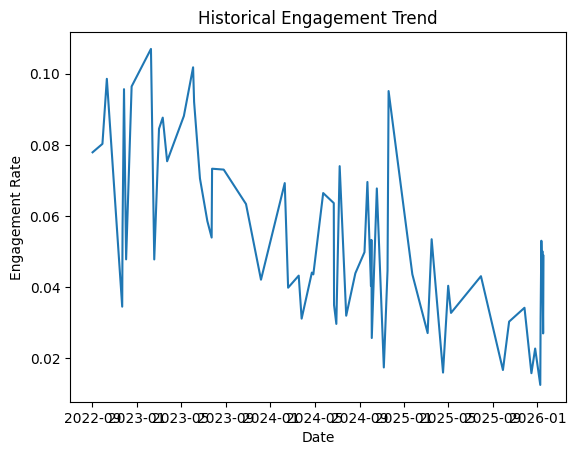

In [5]:
plt.figure()
plt.plot(time_series)
plt.title("Historical Engagement Trend")
plt.xlabel("Date")
plt.ylabel("Engagement Rate")
plt.show()


In [6]:
model = ExponentialSmoothing(
    time_series,
    trend="add",
    seasonal=None
)

model_fit = model.fit()


c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [7]:
forecast_steps = 10
forecast = model_fit.forecast(forecast_steps)

forecast


c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


65    0.026173
66    0.025345
67    0.024516
68    0.023688
69    0.022859
70    0.022031
71    0.021203
72    0.020374
73    0.019546
74    0.018717
dtype: float64

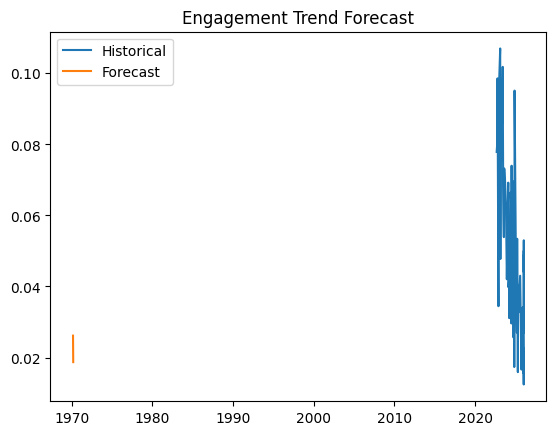

In [8]:
plt.figure()
plt.plot(time_series, label="Historical")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.title("Engagement Trend Forecast")
plt.show()


In [9]:
forecast_df = forecast.reset_index()
forecast_df.columns = ["date", "predicted_engagement_rate"]

forecast_df.to_csv(
    "../data/processed/engagement_forecast.csv",
    index=False
)

print("Trend forecast saved successfully!")


Trend forecast saved successfully!


In [10]:
## Conclusion

'''This module applied time-series forecasting techniques to predict
future engagement trends. The insights support strategic planning
and proactive content optimization.'''


'This module applied time-series forecasting techniques to predict\nfuture engagement trends. The insights support strategic planning\nand proactive content optimization.'